# 🚢 Titanic Hayatta Kalma Tahmini

Bu projede Titanic gemisindeki yolcuların hayatta kalıp kalamayacağını tahmin edeceğiz.

## 📋 Proje İçeriği (Kurs Konularına Göre)

1. **Veri Setini Gözden Geçirme, Train ve Test Split**
2. **Outlier Elimination (Aykırı Değer Eleme)**
3. **Outliers ve Test Set İlişkisi**
4. **Feature Scaling Uygulama**
5. **Train Targetları Güncelleme**
6. **Logistic Regression Classifier**
7. **kNN Classifier**


---
## 📦 Kütüphanelerin Yüklenmesi


In [1]:
# Temel kütüphaneler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn kütüphaneleri
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Uyarıları kapatma
import warnings
warnings.filterwarnings('ignore')

# Grafik ayarları
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("✅ Kütüphaneler başarıyla yüklendi!")


✅ Kütüphaneler başarıyla yüklendi!


---
## 1️⃣ Veri Setini Gözden Geçirme, Train ve Test Split

### 1.1 Veri Setinin Yüklenmesi


In [2]:
# Titanic veri setini Seaborn'dan yüklüyoruz
df = sns.load_dataset('titanic')

print("📊 Veri Seti Boyutu:", df.shape)
print(f"\n👥 Toplam {df.shape[0]} yolcu ve {df.shape[1]} özellik var.")


📊 Veri Seti Boyutu: (891, 15)

👥 Toplam 891 yolcu ve 15 özellik var.


In [3]:
# İlk 5 satıra bakalım
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# Veri seti hakkında genel bilgi
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [5]:
# İstatistiksel özet
df.describe()


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### 1.2 Sütunların Açıklaması

| Sütun | Açıklama |
|-------|----------|
| survived | Hayatta kalma durumu (0=Hayır, 1=Evet) - **HEDEF DEĞİŞKEN** |
| pclass | Bilet sınıfı (1=1.Sınıf, 2=2.Sınıf, 3=3.Sınıf) |
| sex | Cinsiyet |
| age | Yaş |
| sibsp | Gemideki kardeş/eş sayısı |
| parch | Gemideki ebeveyn/çocuk sayısı |
| fare | Bilet ücreti |
| embarked | Biniş limanı (C=Cherbourg, Q=Queenstown, S=Southampton) |
| class | Bilet sınıfı (kategorik) |
| who | Erkek/Kadın/Çocuk |
| adult_male | Yetişkin erkek mi? |
| deck | Güverte |
| embark_town | Biniş şehri |
| alive | Hayatta mı? |
| alone | Yalnız mı? |


In [6]:
# Eksik değerleri kontrol edelim
print("📌 Eksik Değerler:")
print(df.isnull().sum())
print(f"\n📊 Toplam eksik değer: {df.isnull().sum().sum()}")


📌 Eksik Değerler:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

📊 Toplam eksik değer: 869


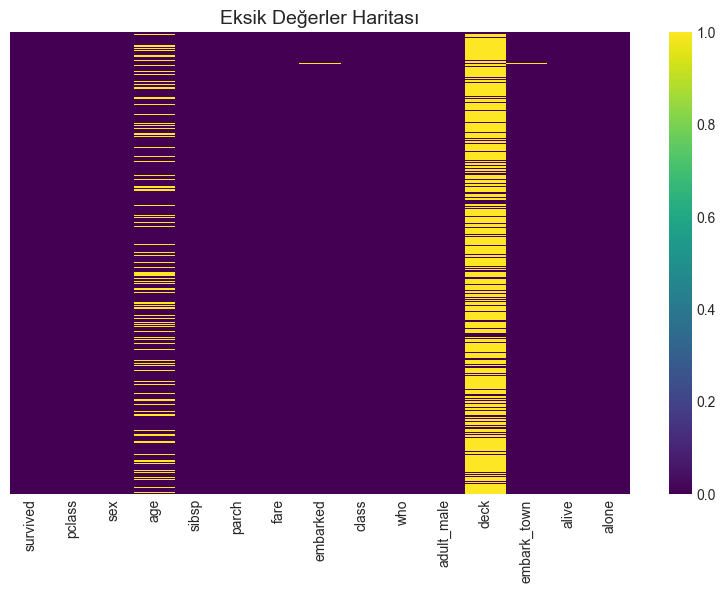

In [7]:
# Eksik değerleri görselleştirelim
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Eksik Değerler Haritası', fontsize=14)
plt.show()


### 1.3 Veri Temizleme ve Hazırlama


In [8]:
# Kullanacağımız sütunları seçelim
# Tekrar eden veya çok fazla eksik değer içeren sütunları çıkarıyoruz
df_clean = df[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'alone']].copy()

print("Seçilen sütunlar:", df_clean.columns.tolist())


Seçilen sütunlar: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'alone']


In [9]:
# Eksik değerleri dolduralım

# Age (Yaş) - Medyan ile doldur
df_clean['age'].fillna(df_clean['age'].median(), inplace=True)

# Embarked - En sık görülen değer ile doldur (mod)
df_clean['embarked'].fillna(df_clean['embarked'].mode()[0], inplace=True)

print("✅ Eksik değerler dolduruldu!")
print(f"\nKalan eksik değer: {df_clean.isnull().sum().sum()}")


✅ Eksik değerler dolduruldu!

Kalan eksik değer: 0


In [10]:
# Kategorik değişkenleri sayısala çevirelim

# Sex: male=1, female=0
df_clean['sex'] = df_clean['sex'].map({'male': 1, 'female': 0})

# Embarked: One-Hot Encoding
df_clean = pd.get_dummies(df_clean, columns=['embarked'], drop_first=True)

# Alone: True=1, False=0
df_clean['alone'] = df_clean['alone'].astype(int)

df_clean.head()


,survived,pclass,sex,age,sibsp,parch,fare,alone,embarked_Q,embarked_S
0,0,3,1,22.0,1,0,7.2500,0,False,True
1,1,1,0,38.0,1,0,71.2833,0,False,False
2,1,3,0,26.0,0,0,7.9250,1,False,True
3,1,1,0,35.0,1,0,53.1000,0,False,True
4,0,3,1,35.0,0,0,8.0500,1,False,True


In [11]:
# Veri setinin son hali
print("📊 Temizlenmiş Veri Seti:")
print(f"Boyut: {df_clean.shape}")
print(f"\nSütunlar: {df_clean.columns.tolist()}")
df_clean.info()


📊 Temizlenmiş Veri Seti:
Boyut: (891, 10)

Sütunlar: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'alone', 'embarked_Q', 'embarked_S']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    891 non-null    int64  
 1   pclass      891 non-null    int64  
 2   sex         891 non-null    int64  
 3   age         891 non-null    float64
 4   sibsp       891 non-null    int64  
 5   parch       891 non-null    int64  
 6   fare        891 non-null    float64
 7   alone       891 non-null    int32  
 8   embarked_Q  891 non-null    bool   
 9   embarked_S  891 non-null    bool   
dtypes: bool(2), float64(2), int32(1), int64(5)
memory usage: 54.1 KB


### 1.4 Hedef ve Özellik Değişkenlerini Ayırma


In [12]:
# Hedef değişken (y) ve özellikler (X)
X = df_clean.drop('survived', axis=1)
y = df_clean['survived']

print(f"📌 Özellikler (X): {X.shape}")
print(f"📌 Hedef (y): {y.shape}")
print(f"\n🎯 Hedef değişken dağılımı:")
print(y.value_counts())
print(f"\nHayatta kalma oranı: {y.mean()*100:.2f}%")


📌 Özellikler (X): (891, 9)
📌 Hedef (y): (891,)

🎯 Hedef değişken dağılımı:
survived
0    549
1    342
Name: count, dtype: int64

Hayatta kalma oranı: 38.38%


### 1.5 Train ve Test Split


In [13]:
# Veriyi eğitim ve test setlerine ayıralım
# test_size=0.2 -> %20 test, %80 eğitim
# random_state=42 -> Tekrar edilebilirlik için
# stratify=y -> Hedef değişkenin oranını korur

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print("✅ Train-Test Split Tamamlandı!")
print(f"\n📊 Eğitim seti: {X_train.shape[0]} örnek")
print(f"📊 Test seti: {X_test.shape[0]} örnek")
print(f"\n📌 Eğitim setinde hayatta kalma oranı: {y_train.mean()*100:.2f}%")
print(f"📌 Test setinde hayatta kalma oranı: {y_test.mean()*100:.2f}%")


✅ Train-Test Split Tamamlandı!

📊 Eğitim seti: 712 örnek
📊 Test seti: 179 örnek

📌 Eğitim setinde hayatta kalma oranı: 38.34%
📌 Test setinde hayatta kalma oranı: 38.55%


---
## 2️⃣ Outlier Elimination (Aykırı Değer Eleme)

### 2.1 Aykırı Değerlerin Tespiti


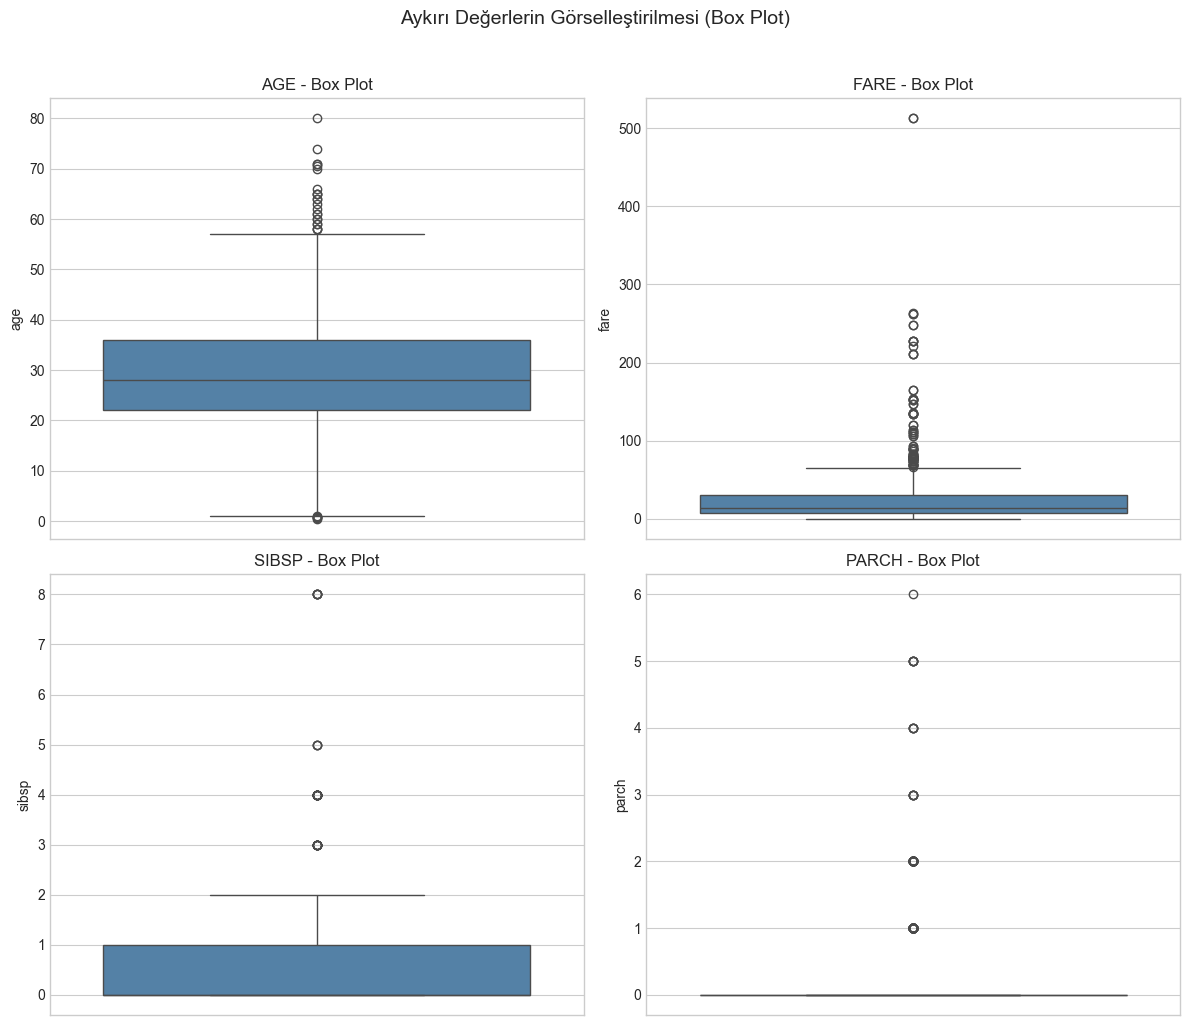

In [14]:
# Sayısal değişkenlerin box plot'ları
numerical_cols = ['age', 'fare', 'sibsp', 'parch']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=X_train, y=col, ax=axes[i], color='steelblue')
    axes[i].set_title(f'{col.upper()} - Box Plot', fontsize=12)

plt.suptitle('Aykırı Değerlerin Görselleştirilmesi (Box Plot)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [15]:
# IQR (Interquartile Range) yöntemi ile aykırı değer tespiti
def detect_outliers_iqr(data, column):
    """
    IQR yöntemi ile aykırı değerleri tespit eder.
    
    IQR = Q3 - Q1
    Alt sınır = Q1 - 1.5 * IQR
    Üst sınır = Q3 + 1.5 * IQR
    """
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    
    return outliers, lower_bound, upper_bound

# Her sütun için aykırı değerleri tespit edelim
print("📊 Aykırı Değer Analizi (IQR Yöntemi)")
print("="*50)

outlier_info = {}
for col in numerical_cols:
    outliers, lower, upper = detect_outliers_iqr(X_train, col)
    outlier_info[col] = {
        'count': len(outliers),
        'percentage': len(outliers) / len(X_train) * 100,
        'lower_bound': lower,
        'upper_bound': upper
    }
    print(f"\n📌 {col.upper()}:")
    print(f"   Alt sınır: {lower:.2f}")
    print(f"   Üst sınır: {upper:.2f}")
    print(f"   Aykırı değer sayısı: {len(outliers)} ({len(outliers)/len(X_train)*100:.2f}%)")


📊 Aykırı Değer Analizi (IQR Yöntemi)

📌 AGE:
   Alt sınır: 1.00
   Üst sınır: 57.00
   Aykırı değer sayısı: 29 (4.07%)

📌 FARE:
   Alt sınır: -26.76
   Üst sınır: 65.66
   Aykırı değer sayısı: 91 (12.78%)

📌 SIBSP:
   Alt sınır: -1.50
   Üst sınır: 2.50
   Aykırı değer sayısı: 33 (4.63%)

📌 PARCH:
   Alt sınır: 0.00
   Üst sınır: 0.00
   Aykırı değer sayısı: 170 (23.88%)


### 2.2 Aykırı Değerlerin Elenmesi (Sadece Eğitim Setinde!)


In [16]:
# Aykırı değerleri eğitim setinden çıkaran fonksiyon
def remove_outliers_iqr(X, y, columns):
    """
    Belirtilen sütunlardaki aykırı değerleri IQR yöntemi ile çıkarır.
    
    ÖNEMLİ: Bu işlem sadece EĞİTİM setine uygulanmalıdır!
    """
    mask = pd.Series([True] * len(X), index=X.index)
    
    for col in columns:
        Q1 = X[col].quantile(0.25)
        Q3 = X[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        col_mask = (X[col] >= lower_bound) & (X[col] <= upper_bound)
        mask = mask & col_mask
    
    return X[mask], y[mask]

# Orijinal boyutları kaydedelim
original_train_size = len(X_train)

# Age ve Fare için outlier'ları çıkaralım (en çok outlier içeren sütunlar)
X_train_clean, y_train_clean = remove_outliers_iqr(X_train, y_train, ['age', 'fare'])

print(f"✅ Aykırı değerler eğitim setinden çıkarıldı!")
print(f"\n📊 Önce: {original_train_size} örnek")
print(f"📊 Sonra: {len(X_train_clean)} örnek")
print(f"📊 Çıkarılan: {original_train_size - len(X_train_clean)} örnek ({(original_train_size - len(X_train_clean))/original_train_size*100:.2f}%)")


✅ Aykırı değerler eğitim setinden çıkarıldı!

📊 Önce: 712 örnek
📊 Sonra: 597 örnek
📊 Çıkarılan: 115 örnek (16.15%)


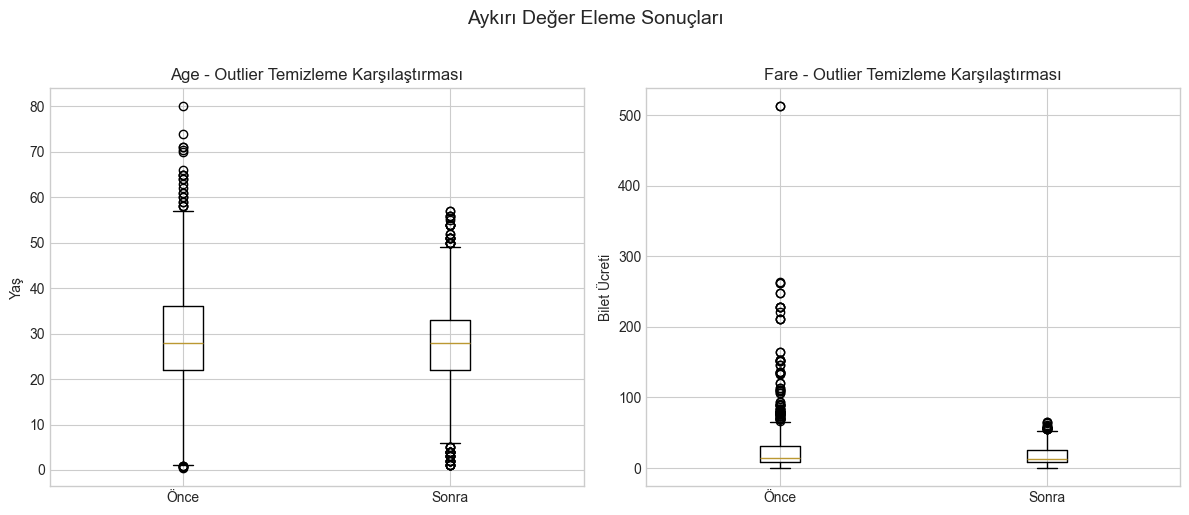

In [17]:
# Temizlenmiş verinin box plot'ları
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Age karşılaştırması
axes[0].boxplot([X_train['age'], X_train_clean['age']], labels=['Önce', 'Sonra'])
axes[0].set_title('Age - Outlier Temizleme Karşılaştırması', fontsize=12)
axes[0].set_ylabel('Yaş')

# Fare karşılaştırması
axes[1].boxplot([X_train['fare'], X_train_clean['fare']], labels=['Önce', 'Sonra'])
axes[1].set_title('Fare - Outlier Temizleme Karşılaştırması', fontsize=12)
axes[1].set_ylabel('Bilet Ücreti')

plt.suptitle('Aykırı Değer Eleme Sonuçları', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


---
## 3️⃣ Outliers ve Test Set İlişkisi

### ⚠️ ÖNEMLİ KURAL:

**Test setindeki aykırı değerleri ASLA çıkarmayız!**

Nedenleri:
1. Test seti gerçek dünyayı simüle eder
2. Gerçek hayatta da aykırı değerlerle karşılaşabiliriz
3. Modelimizin bu değerlerle nasıl başa çıktığını görmek istiyoruz
4. Data leakage (veri sızıntısı) riskini önleriz


In [18]:
# Test setindeki aykırı değerleri inceleyelim (ama çıkarmayacağız!)
print("📊 Test Setindeki Aykırı Değerler (Sadece Bilgi Amaçlı)")
print("="*50)
print("\n⚠️ NOT: Bu değerleri test setinden ÇIKARMIYORUZ!")

for col in ['age', 'fare']:
    # Eğitim setinin istatistiklerini kullanarak test setini değerlendiriyoruz
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    test_outliers = X_test[(X_test[col] < lower_bound) | (X_test[col] > upper_bound)]
    
    print(f"\n📌 {col.upper()}:")
    print(f"   Test setinde aykırı değer sayısı: {len(test_outliers)}")
    print(f"   Oran: {len(test_outliers)/len(X_test)*100:.2f}%")


📊 Test Setindeki Aykırı Değerler (Sadece Bilgi Amaçlı)

⚠️ NOT: Bu değerleri test setinden ÇIKARMIYORUZ!

📌 AGE:
   Test setinde aykırı değer sayısı: 11
   Oran: 6.15%

📌 FARE:
   Test setinde aykırı değer sayısı: 25
   Oran: 13.97%


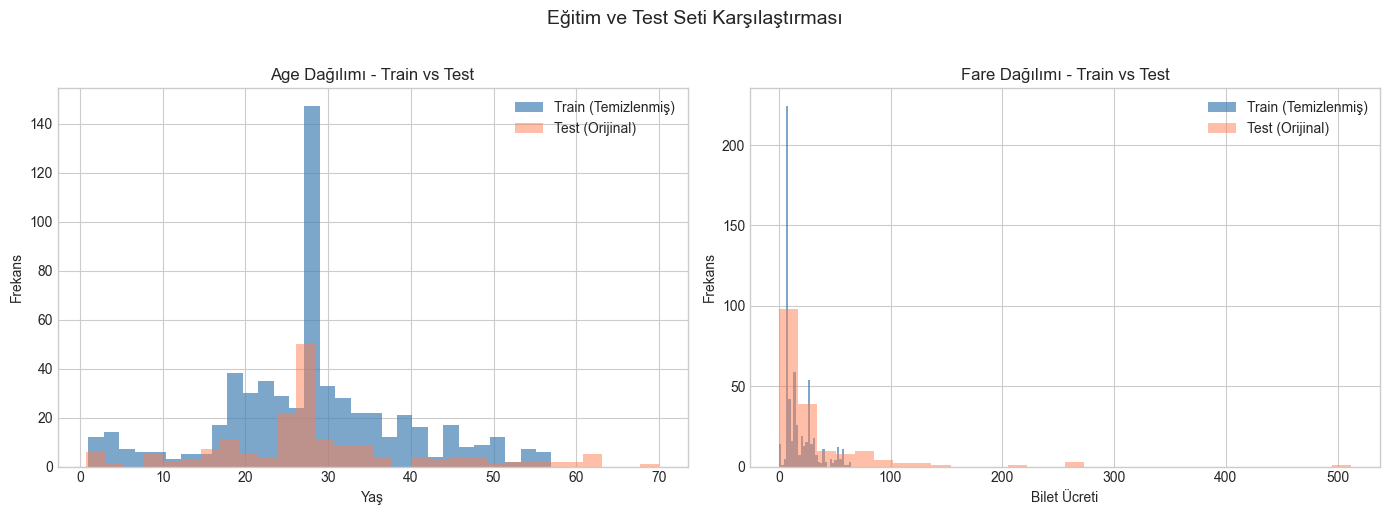

In [19]:
# Train ve Test karşılaştırması
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age dağılımı
axes[0].hist(X_train_clean['age'], bins=30, alpha=0.7, label='Train (Temizlenmiş)', color='steelblue')
axes[0].hist(X_test['age'], bins=30, alpha=0.5, label='Test (Orijinal)', color='coral')
axes[0].set_title('Age Dağılımı - Train vs Test', fontsize=12)
axes[0].set_xlabel('Yaş')
axes[0].set_ylabel('Frekans')
axes[0].legend()

# Fare dağılımı
axes[1].hist(X_train_clean['fare'], bins=30, alpha=0.7, label='Train (Temizlenmiş)', color='steelblue')
axes[1].hist(X_test['fare'], bins=30, alpha=0.5, label='Test (Orijinal)', color='coral')
axes[1].set_title('Fare Dağılımı - Train vs Test', fontsize=12)
axes[1].set_xlabel('Bilet Ücreti')
axes[1].set_ylabel('Frekans')
axes[1].legend()

plt.suptitle('Eğitim ve Test Seti Karşılaştırması', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


---
## 4️⃣ Feature Scaling Uygulama

### Neden Feature Scaling Gerekli?

1. **kNN algoritması** uzaklık hesabı yapar - farklı ölçeklerdeki değişkenler yanıltıcı olabilir
2. **Logistic Regression** gradient descent kullanır - ölçeklenmiş verilerle daha hızlı yakınsar
3. Tüm özelliklerin eşit katkı sağlamasını istiyoruz

### Scaling Yöntemleri:
- **StandardScaler:** Ortalama=0, Standart sapma=1 (Normal dağılım için ideal)
- **MinMaxScaler:** Değerleri 0-1 arasına sıkıştırır


In [20]:
# Scaling öncesi değerlere bakalım
print("📊 Scaling Öncesi İstatistikler (Eğitim Seti):")
print(X_train_clean.describe().round(2))


📊 Scaling Öncesi İstatistikler (Eğitim Seti):
       pclass     sex     age   sibsp   parch    fare   alone
count  597.00  597.00  597.00  597.00  597.00  597.00  597.00
mean     2.50    0.68   28.01    0.43    0.36   17.68    0.65
std      0.72    0.47   11.22    0.89    0.84   13.73    0.48
min      1.00    0.00    1.00    0.00    0.00    0.00    0.00
25%      2.00    0.00   22.00    0.00    0.00    7.90    0.00
50%      3.00    1.00   28.00    0.00    0.00   12.48    1.00
75%      3.00    1.00   33.00    1.00    0.00   26.00    1.00
max      3.00    1.00   57.00    5.00    6.00   65.00    1.00


In [21]:
# StandardScaler ile ölçekleme
scaler = StandardScaler()

# ÖNEMLİ: Scaler'ı sadece EĞİTİM seti üzerinde fit ediyoruz!
# Sonra hem train hem test'i transform ediyoruz

X_train_scaled = scaler.fit_transform(X_train_clean)  # fit + transform
X_test_scaled = scaler.transform(X_test)               # sadece transform

# DataFrame'e çevirelim (görselleştirme için)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_clean.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("✅ Feature Scaling tamamlandı!")
print("\n📊 Scaling Sonrası İstatistikler (Eğitim Seti):")
print(X_train_scaled_df.describe().round(2))


✅ Feature Scaling tamamlandı!

📊 Scaling Sonrası İstatistikler (Eğitim Seti):
       pclass     sex     age   sibsp   parch    fare   alone  embarked_Q  \
count  597.00  597.00  597.00  597.00  597.00  597.00  597.00      597.00   
mean    -0.00    0.00   -0.00    0.00   -0.00    0.00   -0.00        0.00   
std      1.00    1.00    1.00    1.00    1.00    1.00    1.00        1.00   
min     -2.07   -1.44   -2.41   -0.48   -0.43   -1.29   -1.36       -0.31   
25%     -0.69   -1.44   -0.54   -0.48   -0.43   -0.71   -1.36       -0.31   
50%      0.70    0.69   -0.00   -0.48   -0.43   -0.38    0.74       -0.31   
75%      0.70    0.69    0.45    0.64   -0.43    0.61    0.74       -0.31   
max      0.70    0.69    2.59    5.12    6.72    3.45    0.74        3.24   

       embarked_S  
count      597.00  
mean        -0.00  
std          1.00  
min         -1.79  
25%          0.56  
50%          0.56  
75%          0.56  
max          0.56  


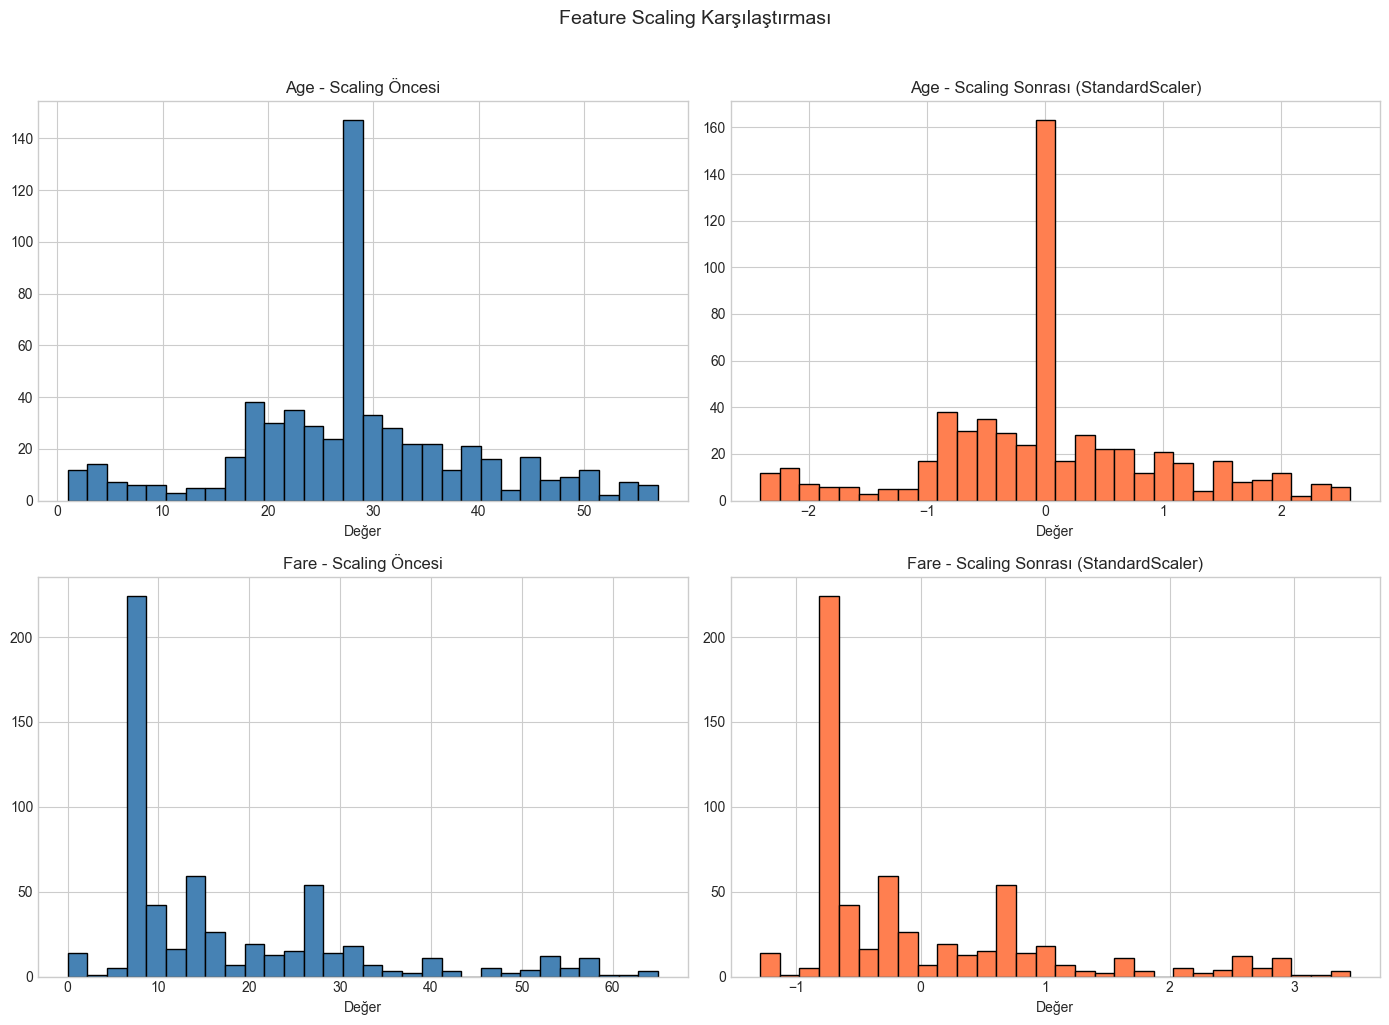

In [22]:
# Scaling öncesi ve sonrası karşılaştırma
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age - Öncesi
axes[0, 0].hist(X_train_clean['age'], bins=30, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Age - Scaling Öncesi', fontsize=12)
axes[0, 0].set_xlabel('Değer')

# Age - Sonrası
axes[0, 1].hist(X_train_scaled_df['age'], bins=30, color='coral', edgecolor='black')
axes[0, 1].set_title('Age - Scaling Sonrası (StandardScaler)', fontsize=12)
axes[0, 1].set_xlabel('Değer')

# Fare - Öncesi
axes[1, 0].hist(X_train_clean['fare'], bins=30, color='steelblue', edgecolor='black')
axes[1, 0].set_title('Fare - Scaling Öncesi', fontsize=12)
axes[1, 0].set_xlabel('Değer')

# Fare - Sonrası
axes[1, 1].hist(X_train_scaled_df['fare'], bins=30, color='coral', edgecolor='black')
axes[1, 1].set_title('Fare - Scaling Sonrası (StandardScaler)', fontsize=12)
axes[1, 1].set_xlabel('Değer')

plt.suptitle('Feature Scaling Karşılaştırması', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


---
## 5️⃣ Train Targetları Güncelleme

Bu bölümde eğitim hedef değişkeninin (y_train) outlier temizleme sonrası doğru şekilde güncellendiğini ve dengelenmiş olduğunu kontrol edeceğiz.


In [23]:
# Temizlenmiş eğitim hedef değişkeni zaten y_train_clean olarak kaydedildi
# Kontrol edelim

print("📊 Hedef Değişken (y) Karşılaştırması")
print("="*50)

print(f"\n📌 Orijinal y_train:")
print(f"   Boyut: {len(y_train)}")
print(f"   Dağılım: {dict(y_train.value_counts())}")
print(f"   Hayatta kalma oranı: {y_train.mean()*100:.2f}%")

print(f"\n📌 Temizlenmiş y_train_clean:")
print(f"   Boyut: {len(y_train_clean)}")
print(f"   Dağılım: {dict(y_train_clean.value_counts())}")
print(f"   Hayatta kalma oranı: {y_train_clean.mean()*100:.2f}%")


📊 Hedef Değişken (y) Karşılaştırması

📌 Orijinal y_train:
   Boyut: 712
   Dağılım: {0: 439, 1: 273}
   Hayatta kalma oranı: 38.34%

📌 Temizlenmiş y_train_clean:
   Boyut: 597
   Dağılım: {0: 395, 1: 202}
   Hayatta kalma oranı: 33.84%


In [24]:
# X ve y'nin boyutlarının eşleştiğinden emin olalım
print("📊 Veri Seti Boyutları Kontrolü")
print("="*50)

print(f"\n✅ Eğitim Seti:")
print(f"   X_train_scaled: {X_train_scaled.shape}")
print(f"   y_train_clean: {y_train_clean.shape}")
print(f"   Eşleşme: {'✅ TAMAM' if X_train_scaled.shape[0] == y_train_clean.shape[0] else '❌ HATA'}")

print(f"\n✅ Test Seti:")
print(f"   X_test_scaled: {X_test_scaled.shape}")
print(f"   y_test: {y_test.shape}")
print(f"   Eşleşme: {'✅ TAMAM' if X_test_scaled.shape[0] == y_test.shape[0] else '❌ HATA'}")


📊 Veri Seti Boyutları Kontrolü

✅ Eğitim Seti:
   X_train_scaled: (597, 9)
   y_train_clean: (597,)
   Eşleşme: ✅ TAMAM

✅ Test Seti:
   X_test_scaled: (179, 9)
   y_test: (179,)
   Eşleşme: ✅ TAMAM


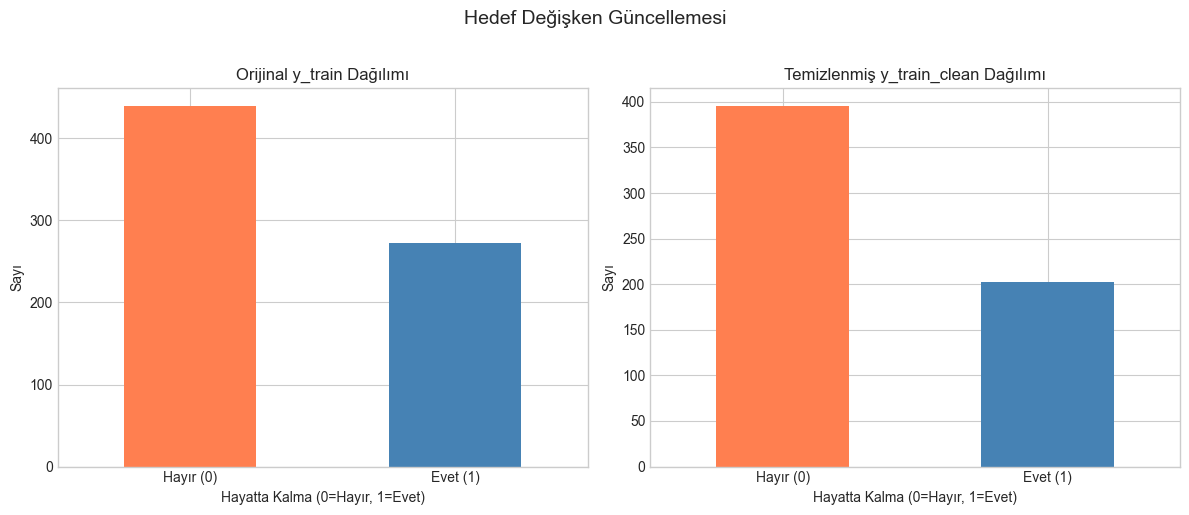

In [25]:
# Hedef değişken dağılımını görselleştirelim
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Orijinal dağılım
y_train.value_counts().plot(kind='bar', ax=axes[0], color=['coral', 'steelblue'])
axes[0].set_title('Orijinal y_train Dağılımı', fontsize=12)
axes[0].set_xlabel('Hayatta Kalma (0=Hayır, 1=Evet)')
axes[0].set_ylabel('Sayı')
axes[0].set_xticklabels(['Hayır (0)', 'Evet (1)'], rotation=0)

# Temizlenmiş dağılım
y_train_clean.value_counts().plot(kind='bar', ax=axes[1], color=['coral', 'steelblue'])
axes[1].set_title('Temizlenmiş y_train_clean Dağılımı', fontsize=12)
axes[1].set_xlabel('Hayatta Kalma (0=Hayır, 1=Evet)')
axes[1].set_ylabel('Sayı')
axes[1].set_xticklabels(['Hayır (0)', 'Evet (1)'], rotation=0)

plt.suptitle('Hedef Değişken Güncellemesi', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


---
## 6️⃣ Logistic Regression Classifier

### 6.1 Model Oluşturma ve Eğitme


In [26]:
# Logistic Regression modeli oluştur
log_reg = LogisticRegression(random_state=42, max_iter=1000)

# Modeli eğit
log_reg.fit(X_train_scaled, y_train_clean)

print("✅ Logistic Regression modeli eğitildi!")


✅ Logistic Regression modeli eğitildi!


### 6.2 Tahmin Yapma


In [27]:
# Tahminler
y_pred_log = log_reg.predict(X_test_scaled)

# Olasılık tahminleri (0-1 arası)
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]

print("📊 İlk 10 tahmin:")
comparison = pd.DataFrame({
    'Gerçek': y_test.values[:10],
    'Tahmin': y_pred_log[:10],
    'Olasılık': y_prob_log[:10].round(3)
})
print(comparison)


📊 İlk 10 tahmin:
   Gerçek  Tahmin  Olasılık
0       0       0     0.093
1       0       0     0.067
2       1       0     0.145
3       0       0     0.034
4       1       1     0.727
5       1       0     0.490
6       1       1     0.669
7       0       0     0.291
8       0       1     0.869
9       0       0     0.205


### 6.3 Model Değerlendirme


In [28]:
# Accuracy (Doğruluk)
accuracy_log = accuracy_score(y_test, y_pred_log)
print(f"🎯 Logistic Regression Accuracy: {accuracy_log*100:.2f}%")


🎯 Logistic Regression Accuracy: 77.09%


In [29]:
# Classification Report
print("📊 Classification Report (Logistic Regression):")
print("="*60)
print(classification_report(y_test, y_pred_log, target_names=['Hayatta Kalamadı', 'Hayatta Kaldı']))


📊 Classification Report (Logistic Regression):
                  precision    recall  f1-score   support

Hayatta Kalamadı       0.82      0.80      0.81       110
   Hayatta Kaldı       0.69      0.72      0.71        69

        accuracy                           0.77       179
       macro avg       0.76      0.76      0.76       179
    weighted avg       0.77      0.77      0.77       179



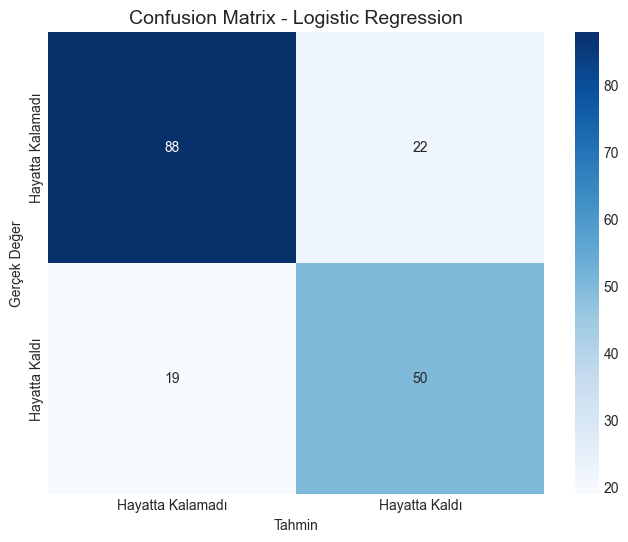


📌 Doğru tahminler: 138
📌 Yanlış tahminler: 41


In [30]:
# Confusion Matrix
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Hayatta Kalamadı', 'Hayatta Kaldı'],
            yticklabels=['Hayatta Kalamadı', 'Hayatta Kaldı'])
plt.title('Confusion Matrix - Logistic Regression', fontsize=14)
plt.ylabel('Gerçek Değer')
plt.xlabel('Tahmin')
plt.show()

print(f"\n📌 Doğru tahminler: {cm_log[0,0] + cm_log[1,1]}")
print(f"📌 Yanlış tahminler: {cm_log[0,1] + cm_log[1,0]}")


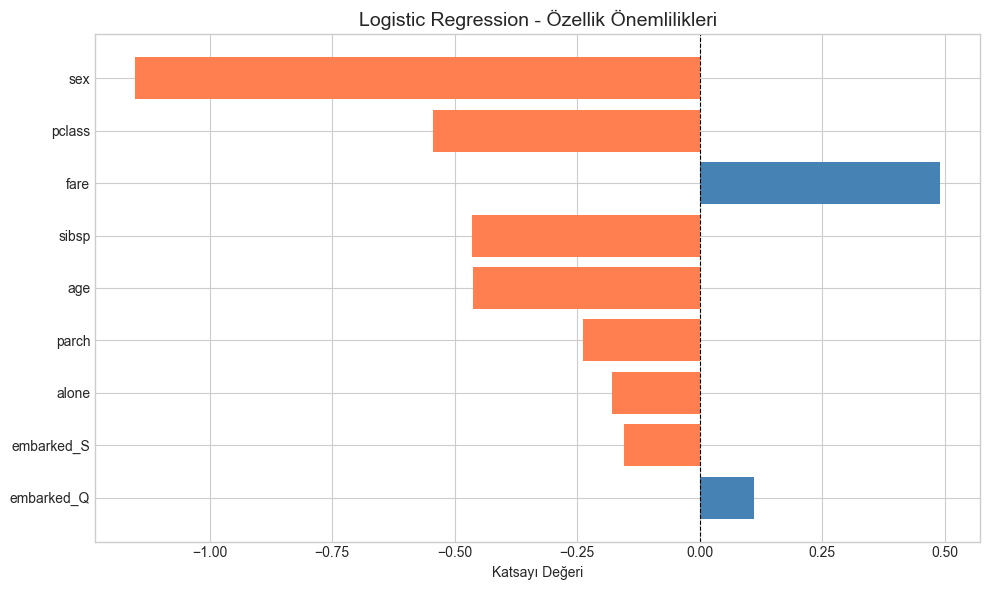


📌 Pozitif katsayı = Hayatta kalma şansını ARTIRIR
📌 Negatif katsayı = Hayatta kalma şansını AZALTIR


In [31]:
# Özellik önemlilikleri (Logistic Regression katsayıları)
feature_importance_log = pd.DataFrame({
    'Özellik': X_train_clean.columns,
    'Katsayı': log_reg.coef_[0]
}).sort_values('Katsayı', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
colors = ['steelblue' if x > 0 else 'coral' for x in feature_importance_log['Katsayı']]
plt.barh(feature_importance_log['Özellik'], feature_importance_log['Katsayı'], color=colors)
plt.xlabel('Katsayı Değeri')
plt.title('Logistic Regression - Özellik Önemlilikleri', fontsize=14)
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n📌 Pozitif katsayı = Hayatta kalma şansını ARTIRIR")
print("📌 Negatif katsayı = Hayatta kalma şansını AZALTIR")


---
## 7️⃣ kNN (K-Nearest Neighbors) Classifier

### 7.1 En İyi K Değerini Bulma


In [32]:
# Farklı k değerleri için accuracy hesaplama
k_values = range(1, 31)
train_scores = []
test_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train_clean)
    
    train_scores.append(knn.score(X_train_scaled, y_train_clean))
    test_scores.append(knn.score(X_test_scaled, y_test))

# En iyi k değeri
best_k = k_values[np.argmax(test_scores)]
best_score = max(test_scores)

print(f"🎯 En iyi k değeri: {best_k}")
print(f"🎯 En iyi test accuracy: {best_score*100:.2f}%")


🎯 En iyi k değeri: 14
🎯 En iyi test accuracy: 80.45%


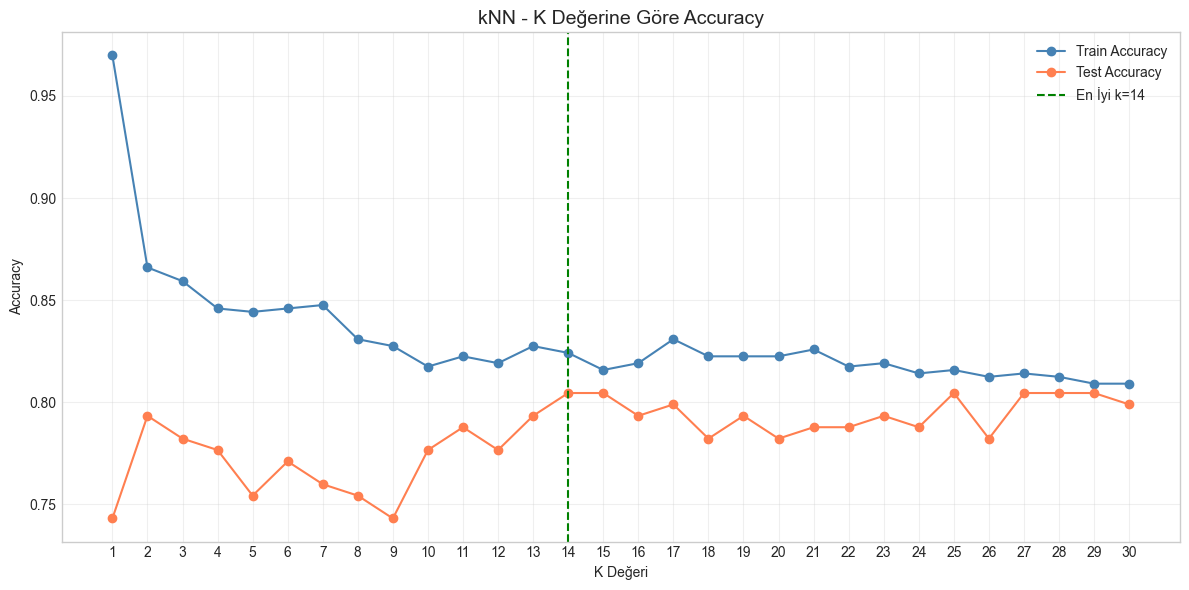

In [33]:
# K değerlerine göre accuracy grafiği
plt.figure(figsize=(12, 6))
plt.plot(k_values, train_scores, 'o-', label='Train Accuracy', color='steelblue')
plt.plot(k_values, test_scores, 'o-', label='Test Accuracy', color='coral')
plt.axvline(x=best_k, color='green', linestyle='--', label=f'En İyi k={best_k}')
plt.xlabel('K Değeri')
plt.ylabel('Accuracy')
plt.title('kNN - K Değerine Göre Accuracy', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.tight_layout()
plt.show()


### 7.2 En İyi K ile Model Eğitme


In [34]:
# En iyi k değeri ile kNN modeli
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train_clean)

# Tahminler
y_pred_knn = knn_best.predict(X_test_scaled)

print(f"✅ kNN modeli (k={best_k}) eğitildi!")


✅ kNN modeli (k=14) eğitildi!


### 7.3 Model Değerlendirme


In [35]:
# Accuracy
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"🎯 kNN (k={best_k}) Accuracy: {accuracy_knn*100:.2f}%")


🎯 kNN (k=14) Accuracy: 80.45%


In [36]:
# Classification Report
print(f"📊 Classification Report (kNN, k={best_k}):")
print("="*60)
print(classification_report(y_test, y_pred_knn, target_names=['Hayatta Kalamadı', 'Hayatta Kaldı']))


📊 Classification Report (kNN, k=14):
                  precision    recall  f1-score   support

Hayatta Kalamadı       0.83      0.86      0.84       110
   Hayatta Kaldı       0.77      0.71      0.74        69

        accuracy                           0.80       179
       macro avg       0.80      0.79      0.79       179
    weighted avg       0.80      0.80      0.80       179



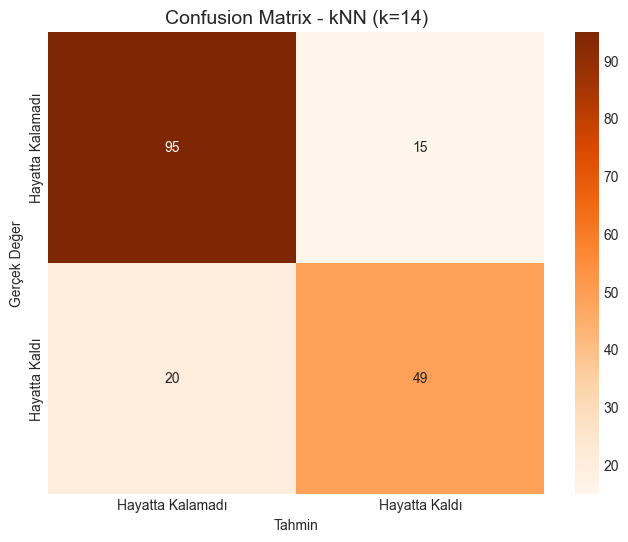


📌 Doğru tahminler: 144
📌 Yanlış tahminler: 35


In [37]:
# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Hayatta Kalamadı', 'Hayatta Kaldı'],
            yticklabels=['Hayatta Kalamadı', 'Hayatta Kaldı'])
plt.title(f'Confusion Matrix - kNN (k={best_k})', fontsize=14)
plt.ylabel('Gerçek Değer')
plt.xlabel('Tahmin')
plt.show()

print(f"\n📌 Doğru tahminler: {cm_knn[0,0] + cm_knn[1,1]}")
print(f"📌 Yanlış tahminler: {cm_knn[0,1] + cm_knn[1,0]}")


---
## 📊 Model Karşılaştırması


In [38]:
# İki modelin karşılaştırması
print("="*60)
print("📊 MODEL KARŞILAŞTIRMASI")
print("="*60)

results = pd.DataFrame({
    'Model': ['Logistic Regression', f'kNN (k={best_k})'],
    'Accuracy': [accuracy_log*100, accuracy_knn*100],
    'Doğru Tahmin': [cm_log[0,0] + cm_log[1,1], cm_knn[0,0] + cm_knn[1,1]],
    'Yanlış Tahmin': [cm_log[0,1] + cm_log[1,0], cm_knn[0,1] + cm_knn[1,0]]
})

print(results.to_string(index=False))


📊 MODEL KARŞILAŞTIRMASI
              Model  Accuracy  Doğru Tahmin  Yanlış Tahmin
Logistic Regression 77.094972           138             41
         kNN (k=14) 80.446927           144             35


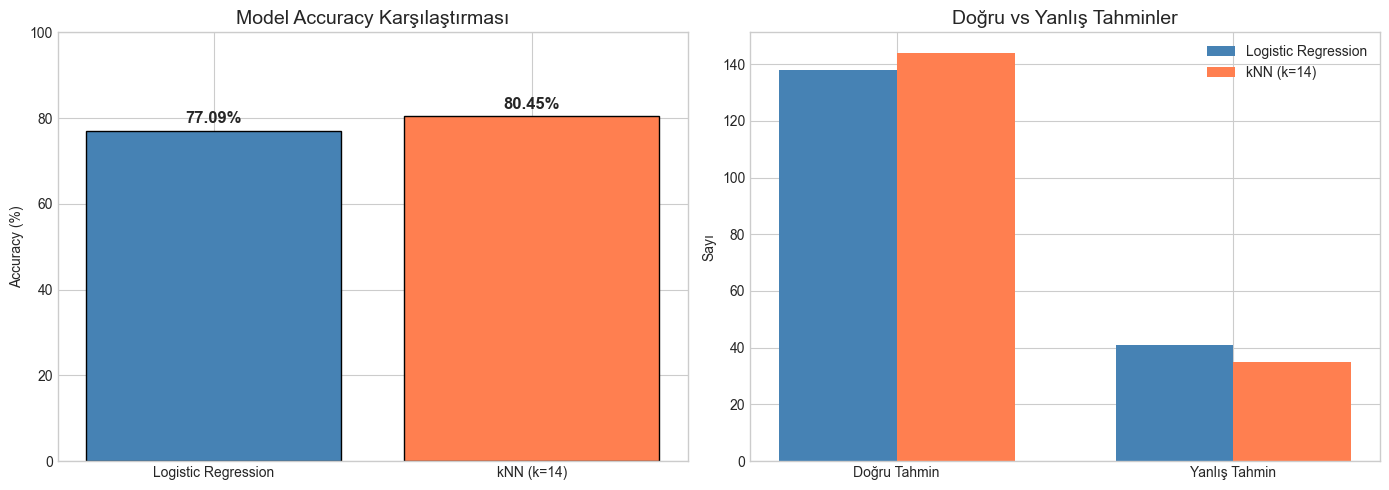

In [39]:
# Görsel karşılaştırma
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy karşılaştırması
models = ['Logistic Regression', f'kNN (k={best_k})']
accuracies = [accuracy_log*100, accuracy_knn*100]
colors = ['steelblue', 'coral']

bars = axes[0].bar(models, accuracies, color=colors, edgecolor='black')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Model Accuracy Karşılaştırması', fontsize=14)
axes[0].set_ylim([0, 100])

# Bar üzerine değer yazma
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{acc:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Confusion Matrix karşılaştırması
x = np.arange(2)
width = 0.35

bars1 = axes[1].bar(x - width/2, [cm_log[0,0] + cm_log[1,1], cm_log[0,1] + cm_log[1,0]], 
                    width, label='Logistic Regression', color='steelblue')
bars2 = axes[1].bar(x + width/2, [cm_knn[0,0] + cm_knn[1,1], cm_knn[0,1] + cm_knn[1,0]], 
                    width, label=f'kNN (k={best_k})', color='coral')

axes[1].set_ylabel('Sayı')
axes[1].set_title('Doğru vs Yanlış Tahminler', fontsize=14)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Doğru Tahmin', 'Yanlış Tahmin'])
axes[1].legend()

plt.tight_layout()
plt.show()


In [40]:
# En iyi modeli belirle
if accuracy_log > accuracy_knn:
    winner = "Logistic Regression"
    winner_acc = accuracy_log
elif accuracy_knn > accuracy_log:
    winner = f"kNN (k={best_k})"
    winner_acc = accuracy_knn
else:
    winner = "Berabere"
    winner_acc = accuracy_log

print("="*60)
print(f"🏆 KAZANAN: {winner}")
print(f"🎯 Accuracy: {winner_acc*100:.2f}%")
print("="*60)


🏆 KAZANAN: kNN (k=14)
🎯 Accuracy: 80.45%


---
## 🎯 Sonuç ve Öğrendiklerimiz

Bu projede aşağıdaki konuları uygulamalı olarak öğrendik:

### ✅ Veri Hazırlama
- Veri setini yükleme ve inceleme
- Eksik değerleri doldurma
- Kategorik değişkenleri sayısala çevirme
- Train/Test split

### ✅ Outlier Analizi
- IQR yöntemi ile aykırı değer tespiti
- Aykırı değerlerin sadece eğitim setinden çıkarılması
- Test setinin dokunulmadan bırakılması (gerçek dünya simülasyonu)

### ✅ Feature Scaling
- StandardScaler kullanımı
- Scaler'ı sadece eğitim seti üzerinde fit etme
- Hem train hem test'i transform etme

### ✅ Model Eğitimi
- Logistic Regression ile sınıflandırma
- kNN ile sınıflandırma
- En iyi k değerini bulma

### ✅ Model Değerlendirme
- Accuracy hesaplama
- Classification report yorumlama
- Confusion matrix analizi
- Model karşılaştırma


In [41]:
# Bonus: Yeni bir yolcu için tahmin yapalım!
print("🚢 Yeni Bir Yolcu İçin Tahmin")
print("="*50)

# Örnek yolcu: 25 yaşında, erkek, 2. sınıf bilet, yalnız seyahat eden
new_passenger = pd.DataFrame({
    'pclass': [2],
    'sex': [1],  # male
    'age': [25],
    'sibsp': [0],
    'parch': [0],
    'fare': [30],
    'alone': [1],
    'embarked_Q': [0],
    'embarked_S': [1]  # Southampton'dan biniş
})

# Ölçekleme
new_passenger_scaled = scaler.transform(new_passenger)

# Tahminler
pred_log = log_reg.predict(new_passenger_scaled)[0]
pred_knn = knn_best.predict(new_passenger_scaled)[0]
prob_log = log_reg.predict_proba(new_passenger_scaled)[0][1]

print("\n👤 Yolcu Bilgileri:")
print("   - Yaş: 25")
print("   - Cinsiyet: Erkek")
print("   - Bilet Sınıfı: 2. Sınıf")
print("   - Yalnız: Evet")
print("   - Biniş Limanı: Southampton")

print(f"\n📊 Tahminler:")
print(f"   Logistic Regression: {'Hayatta Kalır ✅' if pred_log == 1 else 'Hayatta Kalamaz ❌'} (Olasılık: {prob_log*100:.1f}%)")
print(f"   kNN (k={best_k}): {'Hayatta Kalır ✅' if pred_knn == 1 else 'Hayatta Kalamaz ❌'}")


🚢 Yeni Bir Yolcu İçin Tahmin

👤 Yolcu Bilgileri:
   - Yaş: 25
   - Cinsiyet: Erkek
   - Bilet Sınıfı: 2. Sınıf
   - Yalnız: Evet
   - Biniş Limanı: Southampton

📊 Tahminler:
   Logistic Regression: Hayatta Kalamaz ❌ (Olasılık: 33.4%)
   kNN (k=14): Hayatta Kalamaz ❌
